# Inter-Annotator Agreement (IAA)

This notebook computes inter-annotator agreement for a quote annotation task using Krippendorff's alpha.

The annotation task involves classifying quoted expressions into three high-level categories:
- **SQ** – Scare quotes
- **NSQ** – Non-scare quotes
- **SQ+NSQ** – Instances annotated as both

## Contents

1. **Data loading** – Load responses from the main annotator (reference) and a second annotator.
2. **Sample composition** – Distribution of high-level and fine-grained labels in the IAA sample.
3. **High-level agreement** – Krippendorff's alpha treating SQ / NSQ / SQ+NSQ as three classes.
4. **Fine-grained agreement** – Overlap-based Krippendorff's alpha for detailed subcategory labels.
5. **Agreement on sure vs. unsure instances** – Separating cases where annotators expressed uncertainty.
6. **Agreement with LLMs** – Comparing human annotations against LLM predictions.
7. **Majority baseline** – Agreement relative to a majority-class baseline.


In [1]:
from krippendorff_alpha import krippendorff_alpha, overlap_metric, nominal_metric
import json
from utils import get_all_labels, get_labels_one_level, HIGH_LEVEL, FINE_LEVEL
import pdb
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

## 1. Load data


In [ ]:
# 2nd annotator's responses — update this path to point to your annotation file
with open("iaa_sample_2nd_annotator_done_standoff.json") as f:
    annotator_responses = json.load(f)


In [ ]:
# Main annotator's (reference) responses — update this path to point to your annotation file
with open("iaa_reference_annotation_standoff.json") as f:
    reference_responses = json.load(f)


In [4]:
reference_responses_ids = [x['data']['item_order'] for x in reference_responses]
annotator_responses_ids = [x['data']['item_order'] for x in annotator_responses]
print("Item order matches between annotators:", reference_responses_ids == annotator_responses_ids)


Item order matches between annotators: True


In [5]:
annotations = {'reference': reference_responses, 'annotator2':annotator_responses}

## Composition of IAA sample

In [6]:
high_level_labels = [get_labels_one_level(item, HIGH_LEVEL) for item in reference_responses]

high_level_labels_ignore_unsures = [tuple([lb for lb in labels if lb != "Unsure"]) for labels in high_level_labels]

c = Counter(high_level_labels_ignore_unsures)

print("High-level labels distribution (ignoring Unsures):")
for k in c:
    print(f"  {k}  count: {c[k]}  ({c[k] / len(reference_responses) * 100:.2f}%)")


High-level labels distribution (ignoring Unsures):
  ('Non-scare quotes',)  count: 86  (34.40%)
  ('Scare quotes',)  count: 112  (44.80%)
  ('Scare quotes', 'Non-scare quotes')  count: 33  (13.20%)
  ('Scare quotes', 'Non-scare quotes', 'Ambiguous')  count: 19  (7.60%)


In [7]:
fine_level_labels = [get_labels_one_level(item, FINE_LEVEL) for item in reference_responses]

fine_level_labels_ignore_unsures = [tuple(sorted([lb for lb in labels if lb not in ["Unsure", "SQ: Echo Flag"] and "Ambiguous" not in lb])) for labels in fine_level_labels]

c = Counter(fine_level_labels_ignore_unsures)

print(f"Total number of different labels / label combinations: {len(c)}")
print(f"Total number of combinations with more than one label: {len([k for k in c if len(k) > 1])}")

c = dict(sorted(c.items(), key=lambda item: item[1], reverse=True))

print("\nFine-level labels distribution (ignoring Unsures, Ambiguous, and SQ: Echo Flag):")
for k in c:
    print(f"  {k}  count: {c[k]}  ({c[k] / len(reference_responses) * 100:.2f}%)")


Total number of different labels / label combinations: 14
Total number of combinations with more than one label: 6

Fine-level labels distribution (ignoring Unsures, Ambiguous, and SQ: Echo Flag):
  ('SQ: Usage',)  count: 80  (32.00%)
  ('NSQ: Meta-linguistic comment',)  count: 25  (10.00%)
  ('NSQ: Meta-linguistic comment', 'SQ: Usage')  count: 19  (7.60%)
  ('NSQ: Direct quoting',)  count: 17  (6.80%)
  ('SQ: Mixed quotation with attitude',)  count: 17  (6.80%)
  ('NSQ: Emphasis',)  count: 15  (6.00%)
  ('NSQ: Designation', 'SQ: Usage')  count: 15  (6.00%)
  ('NSQ: Emphasis', 'SQ: Usage')  count: 15  (6.00%)
  ('SQ: Word',)  count: 15  (6.00%)
  ('NSQ: Mixed quoting without attitude',)  count: 14  (5.60%)
  ('NSQ: Designation',)  count: 14  (5.60%)
  ('NSQ: Designation', 'NSQ: Meta-linguistic comment', 'SQ: Usage')  count: 2  (0.80%)
  ('NSQ: Meta-linguistic comment', 'NSQ: Mixed quoting without attitude')  count: 1  (0.40%)
  ('NSQ: Mixed quoting without attitude', 'SQ: Mixed quotat

## High-Level Agreement (Global)

### Krippendorff's Alpha


In [8]:
annotators = ['reference', 'annotator2']

annotated_labels = {"reference": [], 'annotator2': []}

for i in range(len(annotations['annotator2'])):
    for annotator in annotators:
        hl_labels = get_labels_one_level(annotations[annotator][i], HIGH_LEVEL, ignore_unsure_ambiguous=True)
        if "Scare quotes" in hl_labels and "Non-scare quotes" in hl_labels:
            hl_labels = ("SQ+NSQ",)
        annotated_labels[annotator].append(hl_labels)

alpha = krippendorff_alpha([annotated_labels['reference'], annotated_labels['annotator2']], nominal_metric, convert_items=str)
print(f"Nominal-based Krippendorff's alpha (high level): {alpha:.2f}")


Nominal-based Krippendorff's alpha (high level): 0.69


### Confusion Matrices


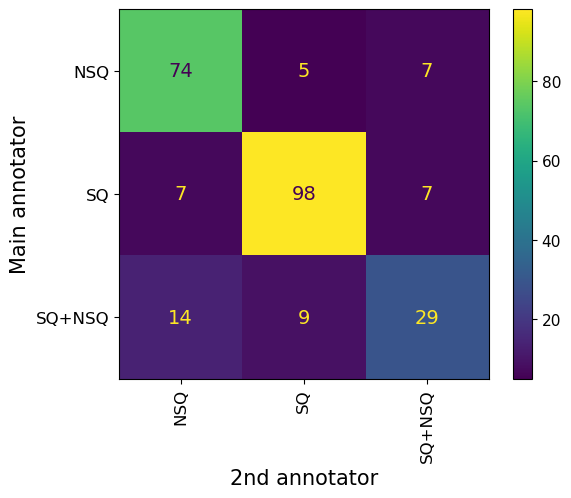

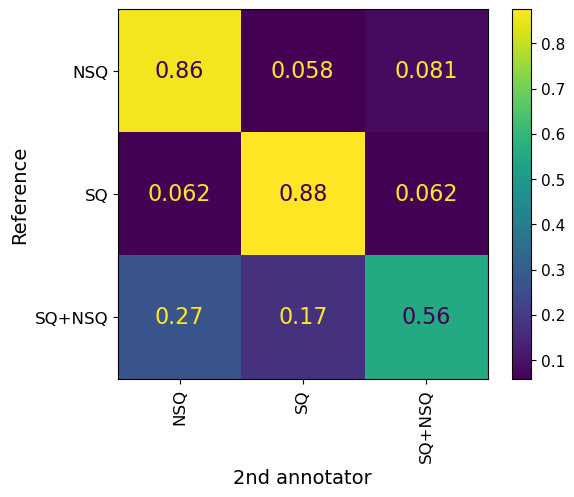

In [9]:
# Convert labels to short form
def convert_label(label):
    if label == ("Scare quotes",):
        return "SQ"
    elif label == ("Non-scare quotes",):
        return "NSQ"
    else:
        return "SQ+NSQ"

ref_labels = [convert_label(x) for x in annotated_labels['reference']]
a2_labels = [convert_label(x) for x in annotated_labels['annotator2']]

disp = ConfusionMatrixDisplay.from_predictions(np.array(ref_labels),
                                               np.array(a2_labels), 
                                               xticks_rotation='vertical')

disp.ax_.set_ylabel("Main annotator", fontsize=15)
disp.ax_.set_xlabel("2nd annotator", fontsize=15)
disp.ax_.tick_params(axis='both', which='major', labelsize=12)
for text in disp.text_.ravel():
    text.set_fontsize(14)
disp.im_.colorbar.ax.tick_params(labelsize=11)


disp2 = ConfusionMatrixDisplay.from_predictions(np.array(ref_labels),
                                               np.array(a2_labels), 
                                               xticks_rotation='vertical', normalize='true')

disp2.ax_.set_ylabel("Reference", fontsize=14)
disp2.ax_.set_xlabel("2nd annotator", fontsize=14)
disp2.ax_.tick_params(axis='both', which='major', labelsize=12)
for text in disp2.text_.ravel():
    text.set_fontsize(16)
disp2.im_.colorbar.ax.tick_params(labelsize=11)

In [10]:
# Find instances where reference = SQ+NSQ and annotator2 = NSQ
mismatches = []

for i in range(len(annotated_labels['reference'])):
    ref_label = annotated_labels['reference'][i]
    a2_label = annotated_labels['annotator2'][i]
    
    if ref_label == ("SQ+NSQ",) and a2_label == ("Non-scare quotes",):
        mismatches.append({
            'index': i,
            'item_order': reference_responses[i]['data']['item_order'],
            'reference': ref_label,
            'annotator2': a2_label
        })

print(f"Found {len(mismatches)} instances where Reference=SQ+NSQ and Annotator2=NSQ\n")
print("Item indices:", [m['index'] for m in mismatches])
print("Item order IDs:", [m['item_order'] for m in mismatches])

mismatch_ids = [m['item_order'] for m in mismatches]


Found 14 instances where Reference=SQ+NSQ and Annotator2=NSQ

Item indices: [5, 11, 34, 35, 46, 53, 84, 118, 130, 147, 186, 210, 218, 232]
Item order IDs: [1420, 7365, 5972, 6124, 5902, 8586, 6842, 2549, 6277, 5623, 6154, 1266, 2062, 7347]


In [11]:
for item_r, item_a in zip(annotations['reference'], annotations['annotator2']):
    if item_r['data']['item_order'] in mismatch_ids:
        assert item_r['data']['item_order'] == item_a['data']['item_order']
        print("item", item_r['data']['item_order'])
        print("ref labels:", get_labels_one_level(item_r, FINE_LEVEL, ignore_unsure_ambiguous=True))
        print("a2 labels:", get_labels_one_level(item_a, FINE_LEVEL, ignore_unsure_ambiguous=True))
        print()

item 1420
ref labels: ('SQ: Usage', 'SQ: Echo Flag', 'NSQ: Designation')
a2 labels: ('NSQ: Meta-linguistic comment', 'NSQ: Designation')

item 7365
ref labels: ('SQ: Usage', 'NSQ: Emphasis')
a2 labels: ('NSQ: Meta-linguistic comment', 'NSQ: Designation')

item 5972
ref labels: ('NSQ: Meta-linguistic comment', 'SQ: Usage', 'SQ: Echo Flag')
a2 labels: ('NSQ: Meta-linguistic comment', 'NSQ: Designation')

item 6124
ref labels: ('SQ: Usage', 'NSQ: Emphasis')
a2 labels: ('NSQ: Emphasis',)

item 5902
ref labels: ('SQ: Usage', 'SQ: Echo Flag', 'NSQ: Emphasis')
a2 labels: ('NSQ: Emphasis',)

item 8586
ref labels: ('SQ: Usage', 'NSQ: Designation')
a2 labels: ('NSQ: Designation',)

item 6842
ref labels: ('SQ: Usage', 'NSQ: Designation')
a2 labels: ('NSQ: Designation',)

item 2549
ref labels: ('SQ: Usage', 'NSQ: Emphasis')
a2 labels: ('NSQ: Designation',)

item 6277
ref labels: ('SQ: Usage', 'NSQ: Emphasis')
a2 labels: ('NSQ: Emphasis',)

item 5623
ref labels: ('SQ: Usage', 'SQ: Echo Flag', 'NSQ:

In [12]:
# Count how many reference annotations contain the NSQ: Emphasis label
count = sum(
    1 for item in annotations['reference']
    if "NSQ: Emphasis" in get_labels_one_level(item, FINE_LEVEL)
)
print(f"Reference annotations containing NSQ: Emphasis: {count}")


Reference annotations containing NSQ: Emphasis: 30


## High-Level Agreement (Per Label)


In [13]:
labels = ["Non-scare quotes", "Scare quotes", "SQ+NSQ"]

annotators = ['reference', 'annotator2']

print("Nominal-based Krippendorff's alpha (high level, per label):")
for label in labels:
    annotated_labels = {"reference": [], 'annotator2': []}
    for i in range(len(annotations['annotator2'])):
        for annotator in annotators:
            hl_labels = get_labels_one_level(annotations[annotator][i], HIGH_LEVEL, ignore_unsure_ambiguous=True)
            if "Scare quotes" in hl_labels and "Non-scare quotes" in hl_labels:
                hl_labels = "SQ+NSQ"
            else:
                hl_labels = hl_labels[0]
            annotated_labels[annotator].append(1 if hl_labels == label else 0)

    alpha = krippendorff_alpha([annotated_labels['reference'], annotated_labels['annotator2']], nominal_metric, convert_items=str)
    print(f"  {label}: {alpha:.2f}")


Nominal-based Krippendorff's alpha (high level, per label):
  Non-scare quotes: 0.71
  Scare quotes: 0.77
  SQ+NSQ: 0.52


## Fine-Grained Agreement (Global)

### Overlap-Based Krippendorff's Alpha


In [14]:
annotators = ['reference', 'annotator2']

annotated_labels = {"reference": [], 'annotator2': []}

for i in range(len(annotations['annotator2'])):
    for annotator in annotators:
        fl_labels = get_labels_one_level(annotations[annotator][i], FINE_LEVEL, ignore_unsure_ambiguous=True)
        annotated_labels[annotator].append(sorted(fl_labels))

alpha = krippendorff_alpha([annotated_labels['reference'], annotated_labels['annotator2']], overlap_metric, convert_items=str)
print(f"Global overlap-based Krippendorff's alpha (fine-grained level): {alpha:.2f}")


Global overlap-based Krippendorff's alpha (fine-grained level): 0.49


### Percentage of Instances with Overlapping Labels


In [15]:
# Re-derive fine-grained label sets locally so this cell is independent of execution order
fine_labels_ref = [set(get_labels_one_level(annotations['reference'][i], FINE_LEVEL, ignore_unsure_ambiguous=True))
                   for i in range(len(annotations['reference']))]
fine_labels_a2  = [set(get_labels_one_level(annotations['annotator2'][i], FINE_LEVEL, ignore_unsure_ambiguous=True))
                   for i in range(len(annotations['annotator2']))]

overlap_presence = []
for ref, a2 in zip(fine_labels_ref, fine_labels_a2):
    if not a2:
        continue  # skip items where annotator 2 provided no label
    overlap_presence.append(int(bool(ref & a2)))  # 1 if any label overlaps

print(f"Percentage of items with some overlap in fine-level labels: {sum(overlap_presence) / len(overlap_presence) * 100:.2f}%")


Percentage of items with some overlap in fine-level labels: 74.40%


### Fine-Grained Agreement (Per Label)

Per-label Krippendorff's alpha for each individual fine-grained subcategory.


In [16]:
total_diff_individual_labels = {'NSQ: Designation',
 'NSQ: Direct quoting',
 'NSQ: Emphasis',
 'NSQ: Meta-linguistic comment',
 'NSQ: Mixed quoting without attitude',
 'SQ: Echo Flag',
 'SQ: Mixed quotation with attitude',
 'SQ: Usage',
 'SQ: Word'}


In [17]:
annotators = ['reference', 'annotator2']

print("Overlap-based Krippendorff's alpha (fine-grained level, per label):")
for label in sorted(total_diff_individual_labels):
    annotated_labels = {"reference": [], 'annotator2': []}
    for i in range(len(annotations['annotator2'])):
        for annotator in annotators:
            fl_labels = get_labels_one_level(annotations[annotator][i], FINE_LEVEL, ignore_unsure_ambiguous=True)
            annotated_labels[annotator].append(int(label in fl_labels))
    alpha = krippendorff_alpha([annotated_labels['reference'], annotated_labels['annotator2']], overlap_metric, convert_items=str)
    print(f"  {label}: {alpha:.2f}")


Overlap-based Krippendorff's alpha (fine-grained level, per label):
  NSQ: Designation: 0.39
  NSQ: Direct quoting: 0.64
  NSQ: Emphasis: 0.38
  NSQ: Meta-linguistic comment: 0.66
  NSQ: Mixed quoting without attitude: 0.06
  SQ: Echo Flag: 0.39
  SQ: Mixed quotation with attitude: 0.27
  SQ: Usage: 0.61
  SQ: Word: 0.67


### Agreement on Common Label Combinations

Agreement for the following co-occurring label pairs (with or without "SQ: Echo Flag" as an optional third label):

- SQ: Usage + NSQ: Meta-linguistic comment
- SQ: Usage + NSQ: Designation
- SQ: Usage + NSQ: Emphasis


In [18]:
annotators = ['reference', 'annotator2']

annotated_labels = {"reference": [], 'annotator2': []}

# Transform annotations to binary: 1 if the item has the target label combination, 0 otherwise.
# The combination is allowed with or without the "SQ: Echo Flag" label.
for i in range(len(annotations['annotator2'])):
    for annotator in annotators:
        fl_labels = get_labels_one_level(annotations[annotator][i], FINE_LEVEL, ignore_unsure_ambiguous=True)
        if len(fl_labels) in [2, 3] and "SQ: Usage" in fl_labels and "NSQ: Meta-linguistic comment" in fl_labels:
            if len(fl_labels) == 2 or (len(fl_labels) == 3 and "SQ: Echo Flag" in fl_labels):
                annotated_labels[annotator].append(1)
            else:
                annotated_labels[annotator].append(0)
        else:
            annotated_labels[annotator].append(0)

alpha = krippendorff_alpha([annotated_labels['reference'], annotated_labels['annotator2']], overlap_metric, convert_items=str)
print(f"Agreement for SQ: Usage + NSQ: Meta-linguistic comment: {alpha:.2f}")


Agreement for SQ: Usage + NSQ: Meta-linguistic comment: 0.47


In [19]:
annotators = ['reference', 'annotator2']

annotated_labels = {"reference": [], 'annotator2': []}

# Transform annotations to binary: 1 if the item has the target label combination, 0 otherwise.
for i in range(len(annotations['annotator2'])):
    for annotator in annotators:
        fl_labels = get_labels_one_level(annotations[annotator][i], FINE_LEVEL, ignore_unsure_ambiguous=True)
        if len(fl_labels) in [2, 3] and "SQ: Usage" in fl_labels and "NSQ: Designation" in fl_labels:
            if len(fl_labels) == 2 or (len(fl_labels) == 3 and "SQ: Echo Flag" in fl_labels):
                annotated_labels[annotator].append(1)
            else:
                annotated_labels[annotator].append(0)
        else:
            annotated_labels[annotator].append(0)

alpha = krippendorff_alpha([annotated_labels['reference'], annotated_labels['annotator2']], overlap_metric, convert_items=str)
print(f"Agreement for SQ: Usage + NSQ: Designation: {alpha:.2f}")


Agreement for SQ: Usage + NSQ: Designation: 0.27


In [20]:
annotators = ['reference', 'annotator2']

annotated_labels = {"reference": [], 'annotator2': []}

# Transform annotations to binary: 1 if the item has the target label combination, 0 otherwise.
for i in range(len(annotations['annotator2'])):
    for annotator in annotators:
        fl_labels = get_labels_one_level(annotations[annotator][i], FINE_LEVEL, ignore_unsure_ambiguous=True)
        if len(fl_labels) in [2, 3] and "SQ: Usage" in fl_labels and "NSQ: Emphasis" in fl_labels:
            if len(fl_labels) == 2 or (len(fl_labels) == 3 and "SQ: Echo Flag" in fl_labels):
                annotated_labels[annotator].append(1)
            else:
                annotated_labels[annotator].append(0)
        else:
            annotated_labels[annotator].append(0)

alpha = krippendorff_alpha([annotated_labels['reference'], annotated_labels['annotator2']], overlap_metric, convert_items=str)
print(f"Agreement for SQ: Usage + NSQ: Emphasis: {alpha:.2f}")


Agreement for SQ: Usage + NSQ: Emphasis: -0.03


In [21]:
# Calculate agreement separately on instances where the reference annotator assigned
# a single fine-grained label vs. a combination of labels.
annotators = ['reference', 'annotator2']

annotated_labels_multi  = {"reference": [], 'annotator2': []}
annotated_labels_single = {"reference": [], 'annotator2': []}

for i in range(len(annotations['annotator2'])):
    ref_fl = get_labels_one_level(annotations['reference'][i], FINE_LEVEL, ignore_unsure_ambiguous=True)
    for annotator in annotators:
        fl_labels = get_labels_one_level(annotations[annotator][i], FINE_LEVEL, ignore_unsure_ambiguous=True)
        if len(ref_fl) > 1:
            annotated_labels_multi[annotator].append(sorted(fl_labels))
        else:
            annotated_labels_single[annotator].append(sorted(fl_labels))

n_multi  = len(annotated_labels_multi['reference'])
n_single = len(annotated_labels_single['reference'])

alpha_multi  = krippendorff_alpha([annotated_labels_multi['reference'],  annotated_labels_multi['annotator2']],  overlap_metric, convert_items=str)
alpha_single = krippendorff_alpha([annotated_labels_single['reference'], annotated_labels_single['annotator2']], overlap_metric, convert_items=str)

print(f"Overlap-based Krippendorff's alpha (fine-grained, multiple labels, n={n_multi}):  {alpha_multi:.2f}")
print(f"Overlap-based Krippendorff's alpha (fine-grained, single label,   n={n_single}): {alpha_single:.2f}")


Overlap-based Krippendorff's alpha (fine-grained, multiple labels, n=77):  0.24
Overlap-based Krippendorff's alpha (fine-grained, single label,   n=173): 0.52


## Agreement on Sure vs. Unsure Instances

Agreement computed separately for instances where annotators expressed uncertainty (by using the "Unsure" label) vs. instances where both were confident.

First, we check the size of each subset:
- Both annotators are sure
- Both annotators are unsure
- Only the reference annotator is unsure
- Only annotator 2 is unsure
- At least one annotator is unsure


In [22]:
unsure_info = []
annotators = ['reference', 'annotator2']

for i in range(len(annotations['annotator2'])):
    item_unsure_info = []
    for annotator in annotators:
        hl_labels = get_labels_one_level(annotations[annotator][i], HIGH_LEVEL, ignore_unsure_ambiguous=False)
        fl_labels = get_labels_one_level(annotations[annotator][i], FINE_LEVEL, ignore_unsure_ambiguous=False)
        item_unsure_info.append("Unsure" in hl_labels or "Unsure" in fl_labels)
    unsure_info.append(item_unsure_info)

n = len(unsure_info)
print(f"Both annotators sure:          {len([x for x in unsure_info if not x[0] and not x[1]])} / {n}")
print(f"Both annotators unsure:        {len([x for x in unsure_info if x[0] and x[1]])} / {n}")
print(f"Only reference unsure:         {len([x for x in unsure_info if x[0] and not x[1]])} / {n}")
print(f"Only annotator 2 unsure:       {len([x for x in unsure_info if not x[0] and x[1]])} / {n}")
print(f"At least one annotator unsure: {len([x for x in unsure_info if True in x])} / {n}")


Both annotators sure:          230 / 250
Both annotators unsure:        0 / 250
Only reference unsure:         14 / 250
Only annotator 2 unsure:       6 / 250
At least one annotator unsure: 20 / 250


### Agreement on Confident Cases

Cases where neither annotator used the "Unsure" label.


In [23]:
indices_to_include = [i for i, x in enumerate(unsure_info) if not x[0] and not x[1]]

annotators = ['reference', 'annotator2']

annotated_labels = {"reference": [], 'annotator2': []}

for i in range(len(annotations['annotator2'])):
    if i not in indices_to_include:
        continue
    for annotator in annotators:
        hl_labels = get_labels_one_level(annotations[annotator][i], HIGH_LEVEL, ignore_unsure_ambiguous=True)
        if "Scare quotes" in hl_labels and "Non-scare quotes" in hl_labels:
            hl_labels = ("SQ+NSQ",)
        annotated_labels[annotator].append(hl_labels)

alpha = krippendorff_alpha([annotated_labels['reference'], annotated_labels['annotator2']], nominal_metric, convert_items=str)
print(f"Nominal-based Krippendorff's alpha (high level, confident cases only, n={len(indices_to_include)}): {alpha:.2f}")


Nominal-based Krippendorff's alpha (high level, confident cases only, n=230): 0.74


### Agreement on Uncertain Cases

Cases where at least one annotator used the "Unsure" label.


In [24]:
indices_to_include = [i for i, x in enumerate(unsure_info) if True in x]

annotators = ['reference', 'annotator2']

annotated_labels = {"reference": [], 'annotator2': []}

for i in range(len(annotations['annotator2'])):
    if i not in indices_to_include:
        continue
    for annotator in annotators:
        hl_labels = get_labels_one_level(annotations[annotator][i], HIGH_LEVEL, ignore_unsure_ambiguous=True)
        if "Scare quotes" in hl_labels and "Non-scare quotes" in hl_labels:
            hl_labels = ("SQ+NSQ",)
        annotated_labels[annotator].append(hl_labels)

alpha = krippendorff_alpha([annotated_labels['reference'], annotated_labels['annotator2']], nominal_metric, convert_items=str)
print(f"Nominal-based Krippendorff's alpha (high level, uncertain cases only, n={len(indices_to_include)}): {alpha:.2f}")


Nominal-based Krippendorff's alpha (high level, uncertain cases only, n=20): 0.07


## Agreement with LLMs

High-level Krippendorff's alpha and per-label breakdown comparing the reference annotator against three LLM systems.


In [ ]:
# Load LLM responses. Each file contains tab-separated (id, prediction) pairs,
# where predictions are encoded as: S = Scare quotes, N = Non-scare quotes, B = Both (SQ+NSQ).

def transform_llm_prediction(pred):
    if pred == "S":
        return ("Scare quotes",)
    elif pred == "N":
        return ("Non-scare quotes",)
    elif pred == "B":
        return ("SQ+NSQ",)
    else:
        raise ValueError(f"Unexpected prediction value: {pred!r}")


best_nonbinary_prompts = {"olmo": 2, "llama70B": 4, "qwen": 4}


predictions_unordered = dict()
predictions = dict()
for model in ['llama70b', 'qwen', 'olmo']:
    predictions_unordered[model] = {}
    predictions[model] = []
    with open("iaa_predictions/" + model + "_prompt" + str(best_nonbinary_prompts[model][0]) + "/id_and_response.txt") as f:
        for l in f:
            idi, response = l.strip().split("\t")
            predictions_unordered[model][int(idi)] = transform_llm_prediction(response.strip())
    for ref_id in reference_responses_ids:
        predictions[model].append(predictions_unordered[model][ref_id])


In [ ]:
for model in predictions:
    print(model)
    print(Counter(predictions[model]))
    

In [ ]:
annotated_labels = {"reference": []}

for modelnum, model in enumerate(predictions):
    annotated_labels[model] = []
    annotations[model] = predictions[model]

    for i in range(len(annotations[model])):
        if modelnum == 0:  # fill reference information only once
            hl_labels = get_labels_one_level(annotations['reference'][i], high_level, ignore_unsure_ambiguous=True)
            if "Scare quotes" in hl_labels and "Non-scare quotes" in hl_labels:
                hl_label = ("SQ+NSQ",)
            else:
                hl_label = hl_labels
            annotated_labels['reference'].append(hl_label)
        annotated_labels[model].append(annotations[model][i])

    alpha = krippendorff_alpha([annotated_labels['reference'], annotated_labels[model]], nominal_metric, convert_items=str)
    ov = [x == y for x, y in zip(annotated_labels['reference'], annotated_labels[model])]
    print(f"{model}:")
    print(f"  Krippendorff's alpha:   {alpha:.2f}")
    print(f"  Exact label agreement:  {sum(ov) / len(ov) * 100:.2f}%")
    print()


### Confusion matrix between Llama 70B and reference annotator

In [ ]:
ref_labels = [convert_label(x) for x in annotated_labels['reference']]
llm_labels = [convert_label(x) for x in annotated_labels['llama70b']]

disp = ConfusionMatrixDisplay.from_predictions(np.array(ref_labels),
                                               np.array(llm_labels),
                                               xticks_rotation='vertical')

disp.ax_.set_ylabel("Reference", fontsize=14)
disp.ax_.set_xlabel("LLM", fontsize=14)
disp.ax_.tick_params(axis='both', which='major', labelsize=12)
for text in disp.text_.ravel():
    text.set_fontsize(16)
disp.im_.colorbar.ax.tick_params(labelsize=11)


In [ ]:
labels = ["Non-scare quotes", "Scare quotes", "SQ+NSQ"]

for model in predictions:
    print(f"{model} (nominal-based Krippendorff's alpha per label):")
    annotations['llm'] = predictions[model]

    for label in labels:
        annotated_labels = {"reference": [], 'llm': []}
        for i in range(len(annotations['llm'])):
            hl_labels = get_labels_one_level(annotations['reference'][i], high_level, ignore_unsure_ambiguous=True)
            if "Scare quotes" in hl_labels and "Non-scare quotes" in hl_labels:
                hl_labels = "SQ+NSQ"
            else:
                hl_labels = hl_labels[0]
            annotated_labels['reference'].append(1 if hl_labels == label else 0)
            hl_label_llm = annotations['llm'][i][0]
            annotated_labels['llm'].append(1 if hl_label_llm == label else 0)

        alpha = krippendorff_alpha([annotated_labels['reference'], annotated_labels['llm']], nominal_metric, convert_items=str)
        print(f"  {label}: {alpha:.2f}")
    print()


## Agreement with Majority Baseline

The majority baseline predicts every instance as a scare quote (the most frequent class in the dev set).

Label distribution in the dev set:
- Scare quotes: 114
- Non-scare quotes: 102
- SQ+NSQ: 34


In [ ]:
annotated_labels = {"reference": [], 'maj': []}

for i in range(len(annotations['reference'])):
    hl_labels = get_labels_one_level(annotations['reference'][i], high_level, ignore_unsure_ambiguous=True)
    if "Scare quotes" in hl_labels and "Non-scare quotes" in hl_labels:
        hl_label = ("SQ+NSQ",)
    else:
        hl_label = hl_labels
    annotated_labels['reference'].append(hl_label)
    annotated_labels['maj'].append(("Scare quotes",))

alpha = krippendorff_alpha([annotated_labels['reference'], annotated_labels['maj']], nominal_metric, convert_items=str)
print(f"Nominal-based Krippendorff's alpha (high level, majority baseline): {alpha:.2f}")


In [ ]:
labels = ["Non-scare quotes", "Scare quotes", "SQ+NSQ"]

print("Nominal-based Krippendorff's alpha (high level, majority baseline, per label):")
for label in labels:
    annotated_labels = {"reference": [], 'maj': []}
    for i in range(len(annotations['reference'])):
        hl_labels = get_labels_one_level(annotations['reference'][i], high_level, ignore_unsure_ambiguous=True)
        if "Scare quotes" in hl_labels and "Non-scare quotes" in hl_labels:
            hl_labels = "SQ+NSQ"
        else:
            hl_labels = hl_labels[0]
        annotated_labels['reference'].append(1 if hl_labels == label else 0)
        annotated_labels['maj'].append(1 if "Scare quotes" == label else 0)

    alpha = krippendorff_alpha([annotated_labels['reference'], annotated_labels['maj']], nominal_metric, convert_items=str)
    print(f"  {label}: {alpha:.2f}")
